## ***Data Science Internship Task 2***

In [37]:
# Step 1: Library Imports & Data Collection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
# Load your dataset (Replace 'student_data.csv' with your actual file name)
df = pd.read_csv('student_data.csv')

print("Data Shape:", df.shape)
display(df.head())

Data Shape: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [39]:
print(df.columns)

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [40]:
# Step 2: Data Preprocessing
# Handle missing values
df.dropna(inplace=True)

# Drop StudentID as it is not a useful feature for prediction
if 'StudentID' in df.columns:
    df.drop(columns=['StudentID'], inplace=True)

# Encode categorical variables if any exist
df = pd.get_dummies(df, drop_first=True)

# Split dataset into features (X) and target variable (y - using 'GPA' as target)
X = df.drop(columns=['GPA'])
y = df['GPA']

# Split dataset into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

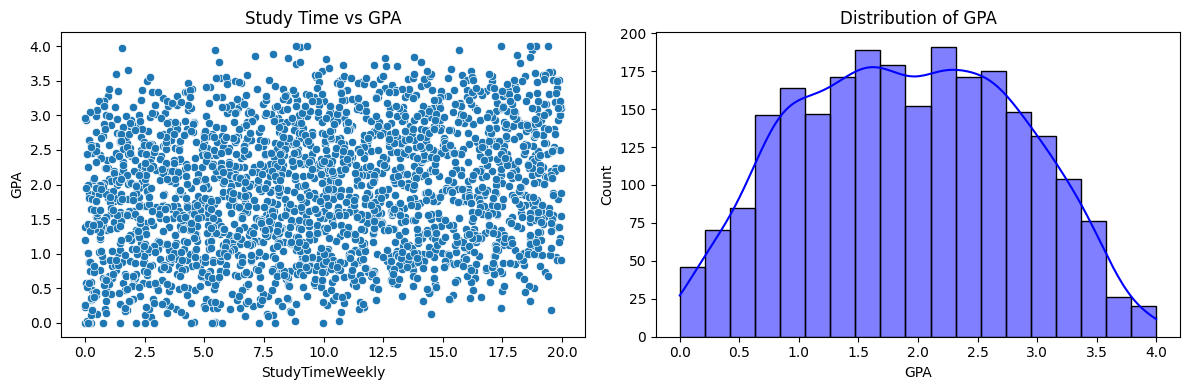

In [41]:
# Step 3: Exploratory Data Analysis (EDA) & Visualizations
plt.figure(figsize=(12, 4))

# Correlation or relationship visualization using correct column names
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='StudyTimeWeekly', y='GPA')
plt.title('Study Time vs GPA')

plt.subplot(1, 2, 2)
sns.histplot(df['GPA'], kde=True, color='blue')
plt.title('Distribution of GPA')

plt.tight_layout()
plt.show()

In [42]:
# Step 4: Model Building (Random Forest Regressor recommended)
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [43]:
# Step 5: Model Training & Testing
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [44]:
# Step 6: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.1703
Mean Squared Error (MSE): 0.0533
R2 Score: 0.9356
